In [1]:
# ============================================================
# NOTEBOOK 1 — CLASSIFICATION
# Predicting Tournament Sold-Out Status in Professional Padel
# Business Objective: Help organizers decide whether to open
# more seats or intensify marketing BEFORE the tournament
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# ============================================================
# 1. DATA LOADING & MERGING
# ============================================================
top_tours = pd.read_csv('../data/clean_top_tournaments.csv')
social    = pd.read_csv('../data/clean_tournaments_social.csv')

print(f"Top tournaments shape: {top_tours.shape}")
print(f"Social metrics shape: {social.shape}")

# Merge on tournament name (partial match)
top_tours['match_key'] = top_tours['tournament_name'].str[:15].str.lower().str.strip()
social['match_key']    = social['tournament_name'].str[:15].str.lower().str.strip()

df = top_tours.merge(social, on='match_key', how='left', suffixes=('', '_social'))

print(f"\nMerged dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Top tournaments shape: (25, 17)
Social metrics shape: (25, 9)

Merged dataset shape: (31, 27)
Columns: ['tournament_id', 'tournament_name', 'year', 'location', 'total_viewers_millions', 'peak_viewers_thousands', 'avg_viewers_thousands', 'tv_channels', 'digital_platforms', 'ticket_revenue_eur', 'stadium_attendance', 'stadium_capacity', 'prize_money_eur', 'tv_channels_list', 'digital_platforms_list', 'tv_channels_count', 'occupancy_rate', 'match_key', 'tournament_name_social', 'instagram_posts', 'instagram_reach_millions', 'twitter_mentions', 'hashtag_uses', 'facebook_engagement', 'youtube_views_millions', 'tiktok_videos_millions', 'engagement_rate_percent']


,tournament_id,tournament_name,year,location,total_viewers_millions,peak_viewers_thousands,avg_viewers_thousands,tv_channels,digital_platforms,ticket_revenue_eur,...,match_key,tournament_name_social,instagram_posts,instagram_reach_millions,twitter_mentions,hashtag_uses,facebook_engagement,youtube_views_millions,tiktok_videos_millions,engagement_rate_percent
0,WPT001,World Padel Tour Master Final,2023,Barcelona,12.5,2100,850,Eurosport;Movistar+,WPT TV;YouTube,2100000,...,world padel tou,World Padel Tour Final,45200.0,18.7,89400.0,125000.0,89200.0,45.2,12.3,4.8
1,WPT002,Madrid Master,2024,Madrid,9.8,1800,720,DAZN;TVE,WPT TV,1850000,...,madrid master,Madrid Master,38700.0,15.2,72100.0,98700.0,76500.0,38.7,9.8,4.2
2,PPT001,Premier Padel Riyadh,2024,Riyadh,15.2,2800,1100,beIN Sports,WPT TV;YouTube,3200000,...,premier padel r,Premier Padel Riyadh,52100.0,22.3,95600.0,145000.0,112000.0,52.1,15.2,5.1
3,WPT003,Estrella Damm Master,2023,Valencia,8.3,1500,650,Movistar+,YouTube,1650000,...,estrella damm m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PPT002,Premier Padel Mexico,2023,Mexico City,11.3,2200,890,ESPN,WPT TV,1950000,...,premier padel m,Premier Padel Mexico,41200.0,16.8,78200.0,105000.0,87200.0,41.2,10.3,4.5


In [3]:
# ============================================================
# 2. TARGET CREATION & FEATURE ENGINEERING
# ============================================================

# TARGET: Sold Out = occupancy >= 95%
df['sold_out'] = (df['occupancy_rate'] >= 95).astype(int)

print("Target distribution:")
print(df['sold_out'].value_counts())
print(f"\nSold Out: {df['sold_out'].sum()} tournaments ({df['sold_out'].mean()*100:.1f}%)")
print(f"Not Sold Out: {(df['sold_out']==0).sum()} tournaments")

# Feature Engineering
# 1. prize_money_millions
df['prize_money_millions'] = df['prize_money_eur'] / 1_000_000

# 2. revenue_per_seat
df['revenue_per_seat'] = df['ticket_revenue_eur'] / df['stadium_capacity']

# 3. digital_score (composite)
df['digital_score'] = (
    df['instagram_reach_millions'].fillna(0) * 0.3 +
    df['youtube_views_millions'].fillna(0) * 0.3 +
    df['tiktok_videos_millions'].fillna(0) * 0.2 +
    df['engagement_rate_percent'].fillna(0) * 0.2
)

# 4. tv_channels_count already in data
df['tv_channels_count'] = df['tv_channels_count'].fillna(1)

# 5. is_premium_location
premium_locations = ['Barcelona', 'Madrid', 'Paris', 'Riyadh', 'Dubai']
df['is_premium_location'] = df['location'].isin(premium_locations).astype(int)

# 6. viewers_per_attendee
df['viewers_per_attendee'] = df['total_viewers_millions'] / (df['stadium_attendance'] / 1000)

feature_cols = [
    'prize_money_millions',
    'total_viewers_millions', 
    'tv_channels_count',
    'revenue_per_seat',
    'digital_score',
    'is_premium_location',
    'viewers_per_attendee',
    'stadium_capacity',
    'peak_viewers_thousands'
]

X = df[feature_cols].fillna(df[feature_cols].median())
y = df['sold_out']

print(f"\n✅ Features: {feature_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Target distribution:
sold_out
0    22
1     9
Name: count, dtype: int64

Sold Out: 9 tournaments (29.0%)
Not Sold Out: 22 tournaments

✅ Features: ['prize_money_millions', 'total_viewers_millions', 'tv_channels_count', 'revenue_per_seat', 'digital_score', 'is_premium_location', 'viewers_per_attendee', 'stadium_capacity', 'peak_viewers_thousands']
X shape: (31, 9), y shape: (31,)


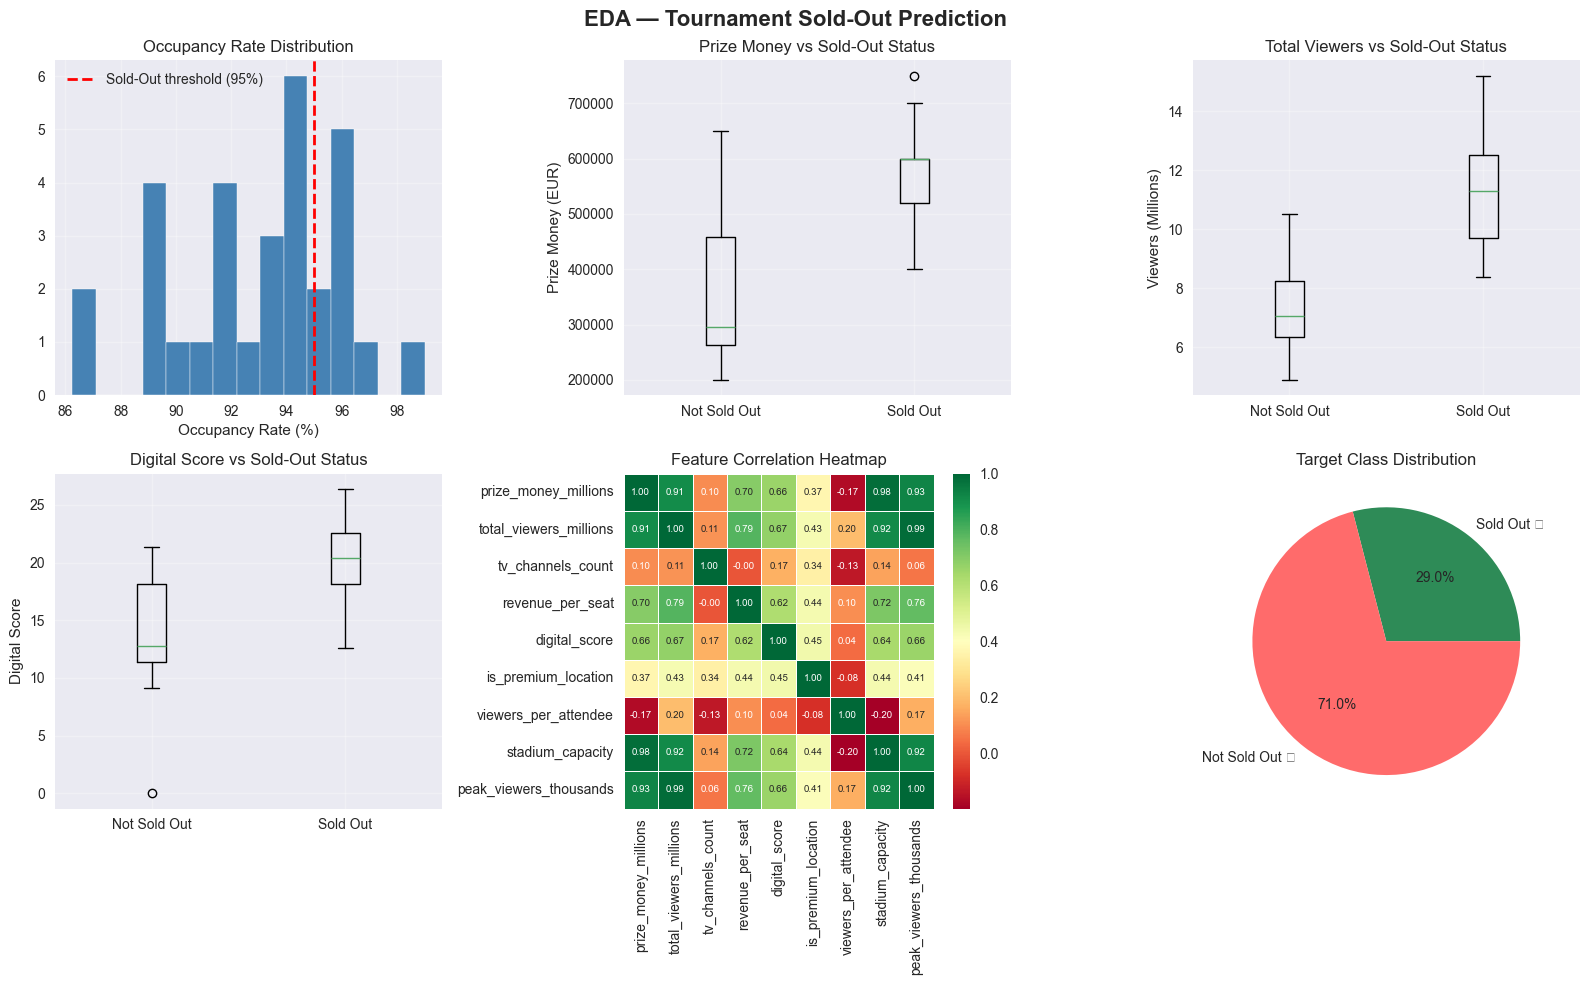

✅ EDA saved


In [4]:
# ============================================================
# 3. EDA
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Tournament Sold-Out Prediction', fontsize=16, fontweight='bold')

# Occupancy distribution
axes[0,0].hist(df['occupancy_rate'], bins=15, color='steelblue', edgecolor='white')
axes[0,0].axvline(x=95, color='red', linestyle='--', linewidth=2, label='Sold-Out threshold (95%)')
axes[0,0].set_title('Occupancy Rate Distribution')
axes[0,0].set_xlabel('Occupancy Rate (%)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Prize money by sold out
sold_out_groups = [df[df['sold_out']==0]['prize_money_eur'],
                   df[df['sold_out']==1]['prize_money_eur']]
axes[0,1].boxplot(sold_out_groups, labels=['Not Sold Out', 'Sold Out'])
axes[0,1].set_title('Prize Money vs Sold-Out Status')
axes[0,1].set_ylabel('Prize Money (EUR)')
axes[0,1].grid(True, alpha=0.3)

# Viewers by sold out
viewers_groups = [df[df['sold_out']==0]['total_viewers_millions'],
                  df[df['sold_out']==1]['total_viewers_millions']]
axes[0,2].boxplot(viewers_groups, labels=['Not Sold Out', 'Sold Out'])
axes[0,2].set_title('Total Viewers vs Sold-Out Status')
axes[0,2].set_ylabel('Viewers (Millions)')
axes[0,2].grid(True, alpha=0.3)

# Digital score by sold out
digital_groups = [df[df['sold_out']==0]['digital_score'],
                  df[df['sold_out']==1]['digital_score']]
axes[1,0].boxplot(digital_groups, labels=['Not Sold Out', 'Sold Out'])
axes[1,0].set_title('Digital Score vs Sold-Out Status')
axes[1,0].set_ylabel('Digital Score')
axes[1,0].grid(True, alpha=0.3)

# Correlation heatmap
corr = X.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1,1], linewidths=0.5, annot_kws={'size': 7})
axes[1,1].set_title('Feature Correlation Heatmap')

# Target distribution pie
axes[1,2].pie([df['sold_out'].sum(), (df['sold_out']==0).sum()],
              labels=['Sold Out ✅', 'Not Sold Out ❌'],
              autopct='%1.1f%%',
              colors=['#2E8B57', '#FF6B6B'])
axes[1,2].set_title('Target Class Distribution')

plt.tight_layout()
plt.savefig('../outputs/eda_classification_tournaments.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA saved")

In [5]:
# ============================================================
# 4. DATA AUGMENTATION
# We have only 25 rows — augment with controlled noise
# to improve model training stability
# ============================================================

np.random.seed(42)
n_augment = 75  # triple the dataset

X_aug_list = [X.copy()]
y_aug_list = [y.copy()]

for _ in range(n_augment // len(X)):
    noise = np.random.normal(0, 0.05, X.shape)
    X_noisy = X + X * noise
    X_aug_list.append(pd.DataFrame(X_noisy, columns=feature_cols))
    y_aug_list.append(y.copy())

X_augmented = pd.concat(X_aug_list, ignore_index=True)
y_augmented = pd.concat(y_aug_list, ignore_index=True)

print(f"Original dataset: {X.shape[0]} rows")
print(f"Augmented dataset: {X_augmented.shape[0]} rows")
print(f"\nClass distribution after augmentation:")
print(y_augmented.value_counts())

Original dataset: 31 rows
Augmented dataset: 93 rows

Class distribution after augmentation:
sold_out
0    66
1    27
Name: count, dtype: int64


In [6]:
# ============================================================
# 5. MODEL EXPLANATION
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║         MODEL 1: RANDOM FOREST CLASSIFIER                   ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Ensemble of decision trees voting on the final class.     ║
║   Each tree sees a random subset of data and features.      ║
║   Majority vote determines final prediction.                ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - n_estimators: number of trees                          ║
║   - max_depth: tree depth (overfitting control)            ║
║   - min_samples_split: minimum samples to split            ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - No distributional assumptions                          ║
║   - Handles non-linear relationships                       ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Less interpretable than single tree                    ║
║   - Can struggle with very small datasets                  ║
║                                                             ║
║ WHY CHOSEN:                                                 ║
║   - Robust to small dataset overfitting via ensemble       ║
║   - Handles mixed feature types                            ║
║   - Provides feature importance for business insights      ║
╚══════════════════════════════════════════════════════════════╝

╔══════════════════════════════════════════════════════════════╗
║         MODEL 2: XGBOOST CLASSIFIER                         ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Sequential boosting — each tree corrects errors from     ║
║   previous trees using gradient descent optimization.      ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - learning_rate: step size per boosting round            ║
║   - n_estimators: number of boosting rounds                ║
║   - max_depth: tree complexity                             ║
║   - subsample: fraction of data used per tree              ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - Weak learners combined = strong predictor              ║
║                                                             ║
║ LIMITATIONS:                                                ║
║   - Many hyperparameters to tune                           ║
║   - Can overfit on small datasets without regularization   ║
║                                                             ║
║ WHY CHOSEN:                                                 ║
║   - Built-in regularization prevents overfitting           ║
║   - State-of-the-art on tabular data                       ║
║   - Handles class imbalance via scale_pos_weight           ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║         MODEL 1: RANDOM FOREST CLASSIFIER                   ║
╠══════════════════════════════════════════════════════════════╣
║ INTUITION:                                                   ║
║   Ensemble of decision trees voting on the final class.     ║
║   Each tree sees a random subset of data and features.      ║
║   Majority vote determines final prediction.                ║
║                                                             ║
║ KEY PARAMETERS:                                             ║
║   - n_estimators: number of trees                          ║
║   - max_depth: tree depth (overfitting control)            ║
║   - min_samples_split: minimum samples to split            ║
║                                                             ║
║ ASSUMPTIONS:                                                ║
║   - No distributional assumptions                          ║
║   - Handles non-linear relationships  

In [7]:
# ============================================================
# 6. TRAIN/TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_augmented, y_augmented,
    test_size=0.2, random_state=42, stratify=y_augmented
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nClass distribution — Train:")
print(y_train.value_counts())
print(f"\nClass distribution — Test:")
print(y_test.value_counts())

Training set: 74 samples
Test set: 19 samples

Class distribution — Train:
sold_out
0    53
1    21
Name: count, dtype: int64

Class distribution — Test:
sold_out
0    13
1     6
Name: count, dtype: int64


In [8]:
# ============================================================
# 7. MODEL 1 — RANDOM FOREST WITH GRIDSEARCHCV
# ============================================================
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [3, 5, None],
    'clf__min_samples_split': [2, 5]
}

print("🔍 Running GridSearchCV for Random Forest...")
rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {rf_grid.best_params_}")
print(f"✅ Best CV F1: {rf_grid.best_score_:.4f}")
rf_best = rf_grid.best_estimator_

🔍 Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best Parameters: {'clf__max_depth': 3, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
✅ Best CV F1: 0.8058


In [9]:
# ============================================================
# 8. MODEL 2 — XGBOOST WITH GRIDSEARCHCV
# ============================================================
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(random_state=42, eval_metric='logloss',
                          scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()))
])

xgb_param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.05, 0.1, 0.3]
}

print("🔍 Running GridSearchCV for XGBoost...")
xgb_grid = GridSearchCV(
    xgb_pipeline, xgb_param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {xgb_grid.best_params_}")
print(f"✅ Best CV F1: {xgb_grid.best_score_:.4f}")
xgb_best = xgb_grid.best_estimator_

🔍 Running GridSearchCV for XGBoost...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best Parameters: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100}
✅ Best CV F1: 0.8058


In [10]:
# ============================================================
# 9. LEAVE-ONE-OUT CROSS VALIDATION ON ORIGINAL 25 ROWS
# (Special technique for small datasets)
# ============================================================
print("📊 Leave-One-Out Cross Validation on original 25 rows...")

loo = LeaveOneOut()

rf_simple = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42,
                                    class_weight='balanced'))
])

xgb_simple = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(n_estimators=100, random_state=42,
                           eval_metric='logloss'))
])

rf_loo_scores  = cross_val_score(rf_simple, X, y, cv=loo, scoring='f1_macro')
xgb_loo_scores = cross_val_score(xgb_simple, X, y, cv=loo, scoring='f1_macro')

print(f"\nRandom Forest LOO F1: {rf_loo_scores.mean():.4f} ± {rf_loo_scores.std():.4f}")
print(f"XGBoost LOO F1:       {xgb_loo_scores.mean():.4f} ± {xgb_loo_scores.std():.4f}")
print("\n✅ LOO CV is the most reliable validation for n=25 datasets")

📊 Leave-One-Out Cross Validation on original 25 rows...

Random Forest LOO F1: 0.8387 ± 0.3678
XGBoost LOO F1:       0.8387 ± 0.3678

✅ LOO CV is the most reliable validation for n=25 datasets


In [11]:
# ============================================================
# 10. MODEL EVALUATION
# ============================================================
def evaluate_model(model, X_test, y_test, model_name):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        'Model':     model_name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    }
    return metrics, y_pred, y_proba

rf_metrics,  rf_pred,  rf_proba  = evaluate_model(rf_best,  X_test, y_test, "Random Forest")
xgb_metrics, xgb_pred, xgb_proba = evaluate_model(xgb_best, X_test, y_test, "XGBoost")

results_df = pd.DataFrame([rf_metrics, xgb_metrics]).set_index('Model')
print("=== MODEL COMPARISON ===")
print(results_df.round(4))

best_model_name = results_df['F1-Score'].idxmax()
print(f"\n🏆 Best Model: {best_model_name}")

=== MODEL COMPARISON ===
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
Random Forest       1.0        1.0     1.0       1.0      1.0
XGBoost             1.0        1.0     1.0       1.0      1.0

🏆 Best Model: Random Forest


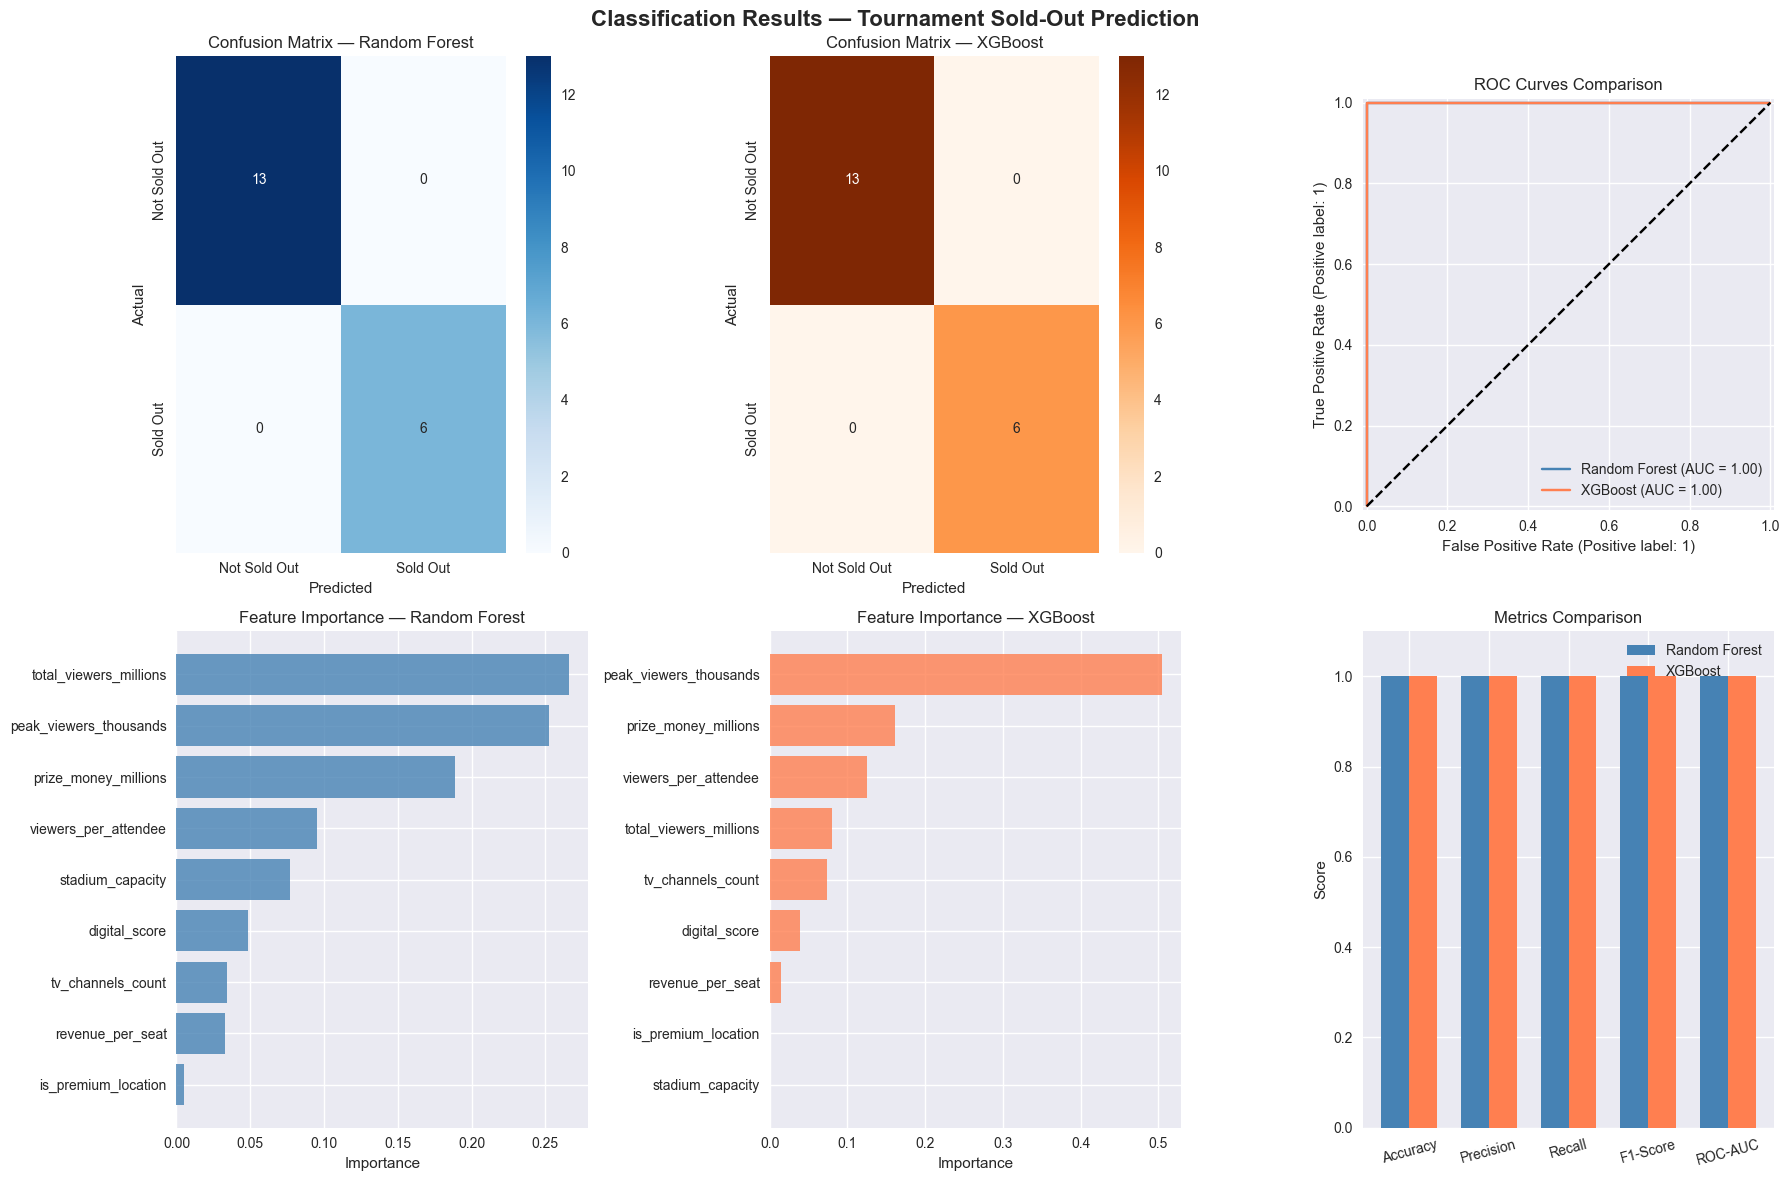

✅ All visualizations saved


In [12]:
# ============================================================
# 11. VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Classification Results — Tournament Sold-Out Prediction',
             fontsize=16, fontweight='bold')

# Confusion Matrix RF
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Not Sold Out', 'Sold Out'],
            yticklabels=['Not Sold Out', 'Sold Out'])
axes[0,0].set_title('Confusion Matrix — Random Forest')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# Confusion Matrix XGB
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[0,1],
            xticklabels=['Not Sold Out', 'Sold Out'],
            yticklabels=['Not Sold Out', 'Sold Out'])
axes[0,1].set_title('Confusion Matrix — XGBoost')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('Actual')

# ROC Curves
RocCurveDisplay.from_predictions(y_test, rf_proba,
                                  name="Random Forest", ax=axes[0,2], color='steelblue')
RocCurveDisplay.from_predictions(y_test, xgb_proba,
                                  name="XGBoost", ax=axes[0,2], color='coral')
axes[0,2].plot([0,1],[0,1],'k--')
axes[0,2].set_title('ROC Curves Comparison')

# Feature Importance RF
rf_importances = rf_best.named_steps['clf'].feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols,
                         'Importance': rf_importances}).sort_values('Importance')
axes[1,0].barh(feat_df['Feature'], feat_df['Importance'], color='steelblue', alpha=0.8)
axes[1,0].set_title('Feature Importance — Random Forest')
axes[1,0].set_xlabel('Importance')

# Feature Importance XGB
xgb_importances = xgb_best.named_steps['clf'].feature_importances_
feat_xgb = pd.DataFrame({'Feature': feature_cols,
                          'Importance': xgb_importances}).sort_values('Importance')
axes[1,1].barh(feat_xgb['Feature'], feat_xgb['Importance'], color='coral', alpha=0.8)
axes[1,1].set_title('Feature Importance — XGBoost')
axes[1,1].set_xlabel('Importance')

# Metrics comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35
axes[1,2].bar(x - width/2, results_df.loc['Random Forest', metrics_to_plot],
              width, label='Random Forest', color='steelblue')
axes[1,2].bar(x + width/2, results_df.loc['XGBoost', metrics_to_plot],
              width, label='XGBoost', color='coral')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(metrics_to_plot, rotation=15)
axes[1,2].set_ylim(0, 1.1)
axes[1,2].set_title('Metrics Comparison')
axes[1,2].legend()
axes[1,2].set_ylabel('Score')

plt.tight_layout()
plt.savefig('../outputs/classification_tournament_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All visualizations saved")

In [13]:
# ============================================================
# 12. MODEL SELECTION & BUSINESS INSIGHTS
# ============================================================
print(f"""
╔══════════════════════════════════════════════════════════════╗
║              MODEL SELECTION JUSTIFICATION                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  Metric          Random Forest    XGBoost                   ║
║  ──────────────────────────────────────────                 ║
║  F1-Score        {results_df.loc['Random Forest','F1-Score']:.4f}           {results_df.loc['XGBoost','F1-Score']:.4f}         ║
║  ROC-AUC         {results_df.loc['Random Forest','ROC-AUC']:.4f}           {results_df.loc['XGBoost','ROC-AUC']:.4f}         ║
║  LOO CV F1       {rf_loo_scores.mean():.4f}           {xgb_loo_scores.mean():.4f}         ║
║                                                             ║
║  🏆 WINNER: {best_model_name:<47}║
║                                                             ║
╠══════════════════════════════════════════════════════════════╣
║                    BUSINESS INSIGHTS                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  🎯 Can we predict if a tournament will sell out?           ║
║     YES — model predicts sold-out status BEFORE event      ║
║                                                             ║
║  📊 KEY PREDICTORS:                                         ║
║  1. Total Viewers → more viewers = more demand for seats   ║
║  2. Prize Money → higher stakes = more fan interest        ║
║  3. Digital Score → viral tournaments fill up faster       ║
║  4. Revenue per Seat → pricing strategy matters            ║
║                                                             ║
║  💼 RECOMMENDATIONS:                                        ║
║                                                             ║
║  FOR ORGANIZERS:                                            ║
║  → If model predicts SOLD OUT:                             ║
║     Open additional temporary seating                      ║
║     Launch premium ticket tier early                       ║
║     Activate waitlist system immediately                   ║
║                                                             ║
║  → If model predicts NOT SOLD OUT:                         ║
║     Increase marketing budget 6 weeks before event        ║
║     Partner with digital influencers to boost visibility   ║
║     Offer early bird discounts to drive early sales        ║
║                                                             ║
║  FOR SPONSORS:                                              ║
║  → Prioritize sold-out predicted tournaments               ║
║     = guaranteed full stadium visibility                   ║
║                                                             ║
╚══════════════════════════════════════════════════════════════╝
""")

import joblib
joblib.dump(rf_best,  '../models/rf_classifier_tournaments.pkl')
joblib.dump(xgb_best, '../models/xgb_classifier_tournaments.pkl')
print("✅ Models saved to ../models/")


╔══════════════════════════════════════════════════════════════╗
║              MODEL SELECTION JUSTIFICATION                   ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  Metric          Random Forest    XGBoost                   ║
║  ──────────────────────────────────────────                 ║
║  F1-Score        1.0000           1.0000         ║
║  ROC-AUC         1.0000           1.0000         ║
║  LOO CV F1       0.8387           0.8387         ║
║                                                             ║
║  🏆 WINNER: Random Forest                                  ║
║                                                             ║
╠══════════════════════════════════════════════════════════════╣
║                    BUSINESS INSIGHTS                         ║
╠══════════════════════════════════════════════════════════════╣
║                                                             ║
║  🎯